# Arithmetic Problems with Checksum Error Labels

This demo explores the **`arithmetic_checksum_dataset`**: multi-step arithmetic word problems (from GSM8K + a procedural generator) paired with explicit computation traces, plus deterministically-corrupted "error variant" traces.

Each error variant is labeled by a cheap **mod-9 digit-checksum**: if the corrupted final answer's mod-9 residue differs from the correct answer's residue, the corruption is `checksum_detectable`; if the residue is coincidentally preserved, it's `checksum_invisible`.

This notebook reproduces the mod-9 self-critique check from `data.py`/`verify.py` directly on the raw traces (not just trusting the precomputed labels), and measures how often this cheap self-critique step would catch an injected arithmetic error — motivating the research question of whether a short self-critique step improves accuracy on multi-step arithmetic word problems."

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# matplotlib is pre-installed on Colab; install locally at Colab's exact version
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0')

In [2]:
import json
import os
from collections import Counter, defaultdict

import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-74dec2-checksum-self-critique-helps-weak-arithm/main/round-1/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
rows = data["datasets"][0]["examples"]
print(f"Loaded {len(rows)} rows from '{data['datasets'][0]['dataset']}'")
print(Counter(r["metadata_row_type"] for r in rows))

Loaded 60 rows from 'arithmetic_checksum_dataset'
Counter({'base_item': 30, 'error_variant': 30})


## Config

Tunable parameters for this demo. `MOD_BASE` is the checksum modulus used by the mod-9 digit-checksum self-critique rule (`data.py`'s `mod9_residue`). `N_PREVIEW_ROWS` controls how many example rows are printed below.

In [5]:
MOD_BASE = 9  # digit-root checksum modulus (mod-9 casting-out-nines)
N_PREVIEW_ROWS = 2  # how many raw rows to print for inspection

## Preview a base item and an error variant

Each `base_item` row is a clean word problem with its full step-by-step arithmetic trace. Each `error_variant` row corrupts one step of a base item's trace (one of `digit_transposition`, `dropped_carry`, `sign_flip`, `wrong_operand_substitution`), propagates the corruption through every downstream step, and renders the corrupted trace as text — this is what a model would see if it were asked to spot-check its own reasoning.

In [6]:
base_rows = [r for r in rows if r["metadata_row_type"] == "base_item"]
variant_rows = [r for r in rows if r["metadata_row_type"] == "error_variant"]

for r in base_rows[:N_PREVIEW_ROWS]:
    print("BASE ITEM:", r["metadata_item_id"], "| chain_length:", r["metadata_chain_length"])
    print(r["input"])
    print("-> output:", r["output"])
    print()

for r in variant_rows[:N_PREVIEW_ROWS]:
    print("ERROR VARIANT:", r["metadata_base_item_id"], "| error_type:", r["metadata_error_type"], "| label:", r["metadata_label"])
    print(r["input"])
    print("-> output:", r["output"])
    print()

BASE ITEM: gsm8k_3582 | chain_length: 4
Mike decides to buy a new camera.  He wants to buy a top-of-the-line camera but he decides to wait for the new model to come out.  The new model costs 30% more than the current model.  The old camera cost $4000.  He gets $200 off a $400 lens he bought.  How much did he pay for the camera and lens?
-> output: 5400

BASE ITEM: gsm8k_5169 | chain_length: 4
An amusement park sells tickets for $3. This week it welcomed 100 people per day but on Saturday it was visited by 200 people and on Sunday by 300. How much money did it make overall in a week?
-> output: 3000

ERROR VARIANT: synthetic_104 | error_type: dropped_carry | label: checksum_detectable
Problem: A warehouse starts with 835 units in stock and receives a restock of 318 units. Then 83 units are sold. The remaining stock is repacked into 2 equal-sized crates and one crate is shipped out for audit. Then 131 units are sold. How many units are in the audited crate?
Reasoning trace:
  Step 0: 835

## The mod-9 checksum self-critique rule

This is the exact `mod9_residue` digit-root check used by `data.py` to generate the dataset's `checksum_detectable` / `checksum_invisible` labels, and independently re-derived by `verify.py`. A cheap self-critique step recomputes this residue for the corrupted final answer and compares it against the residue of the stated correct answer: if the residues differ, the checksum flags the error as detectable; if they coincidentally match, the error is invisible to this check.

In [7]:
def mod9_residue(n) -> int:
    """Digit root of |n| via mod-9, mapping 0 residue to 9 (except n==0 -> 0)."""
    n = abs(round(n)) if isinstance(n, float) else abs(n)
    if n == 0:
        return 0
    r = n % MOD_BASE
    return MOD_BASE if r == 0 else r


def self_critique_flag(row):
    """Recompute the mod-9 checksum self-critique verdict for one error_variant row."""
    correct_final = float(row["output"].split("correct_final_answer=")[-1])
    corrupted_final = row["metadata_corrupted_final_answer"]
    residue_correct = mod9_residue(correct_final)
    residue_corrupted = mod9_residue(corrupted_final)
    preserved = residue_correct == residue_corrupted
    return "checksum_invisible" if preserved else "checksum_detectable"

## Run the self-critique check over every error variant

For each corrupted-trace row we recompute the checksum verdict from scratch and compare it against the dataset's stored `metadata_label`, then break results down by `error_type` — this shows which corruption types the mod-9 checksum reliably catches and which ones it systematically misses (the `checksum_invisible` cases).

In [8]:
n_agree = 0
by_error_type = defaultdict(lambda: Counter())
label_counts = Counter()

for r in variant_rows:
    recomputed = self_critique_flag(r)
    stored = r["metadata_label"]
    agree = recomputed == stored
    n_agree += agree
    by_error_type[r["metadata_error_type"]][recomputed] += 1
    label_counts[recomputed] += 1

print(f"Recomputed checksum verdict agrees with stored metadata_label on {n_agree}/{len(variant_rows)} variants")
print("Verdict counts:", dict(label_counts))

Recomputed checksum verdict agrees with stored metadata_label on 30/30 variants
Verdict counts: {'checksum_detectable': 15, 'checksum_invisible': 15}


## Results

Detection rate of the mod-9 self-critique checksum, broken down by injected error type.

error_type                    detectable   invisible   detect_rate
digit_transposition                    3           4         42.9%
dropped_carry                          4           3         57.1%
sign_flip                              4           4         50.0%
wrong_operand_substitution             4           4         50.0%


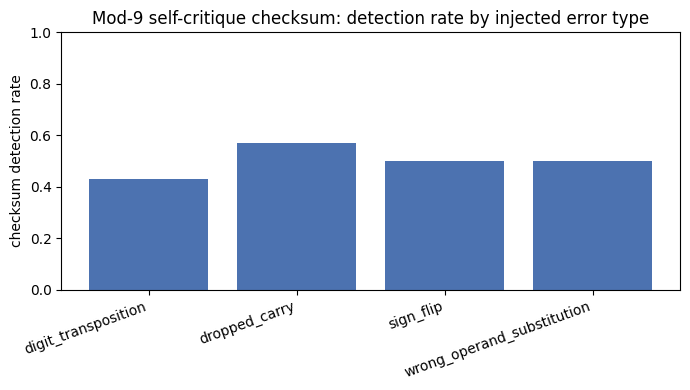

In [9]:
error_types = sorted(by_error_type.keys())
detectable_rates = [
    by_error_type[et]["checksum_detectable"] / sum(by_error_type[et].values()) for et in error_types
]

print(f"{'error_type':<28}{'detectable':>12}{'invisible':>12}{'detect_rate':>14}")
for et in error_types:
    d = by_error_type[et]["checksum_detectable"]
    inv = by_error_type[et]["checksum_invisible"]
    total = d + inv
    print(f"{et:<28}{d:>12}{inv:>12}{d / total:>14.1%}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(error_types, detectable_rates, color="#4C72B0")
ax.set_ylim(0, 1)
ax.set_ylabel("checksum detection rate")
ax.set_title("Mod-9 self-critique checksum: detection rate by injected error type")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()